In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, ConfusionMatrixDisplay
)


In [44]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [45]:
print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (59598, 24)
Test : (14900, 24)


In [46]:
print("\nMissing values:", train_df.isnull().sum().sum())
print("Duplicate rows:", train_df.duplicated().sum())


Missing values: 0
Duplicate rows: 0


In [47]:
train_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


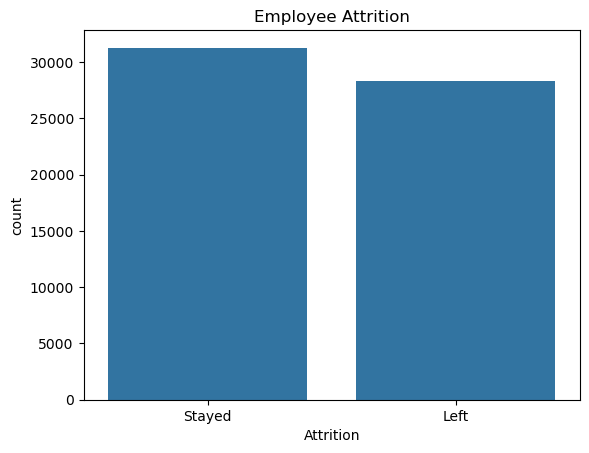

Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


In [48]:
sns.countplot(data=train_df, x="Attrition")
plt.title("Employee Attrition")
plt.show()

print(train_df["Attrition"].value_counts(normalize=True) * 100)


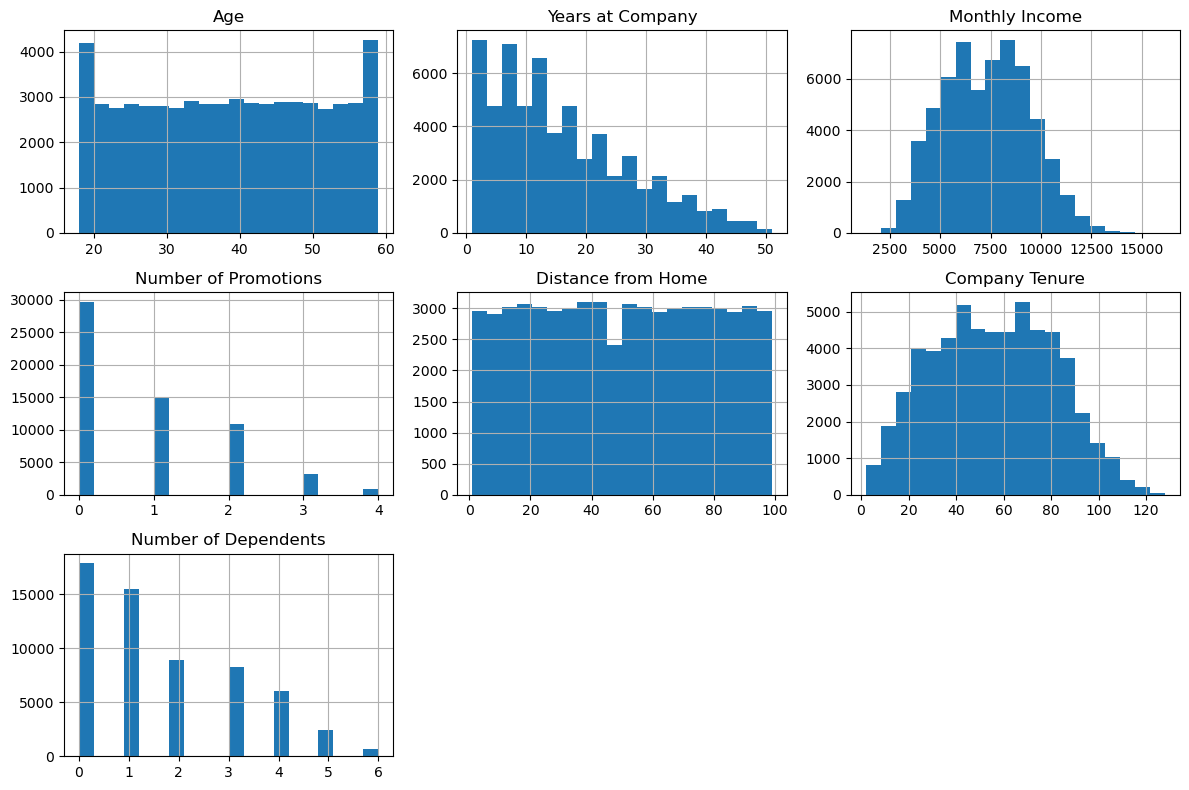

In [49]:
num = [
    "Age", "Years at Company", "Monthly Income",
    "Number of Promotions", "Distance from Home",
    "Company Tenure", "Number of Dependents"
]

train_df[num].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


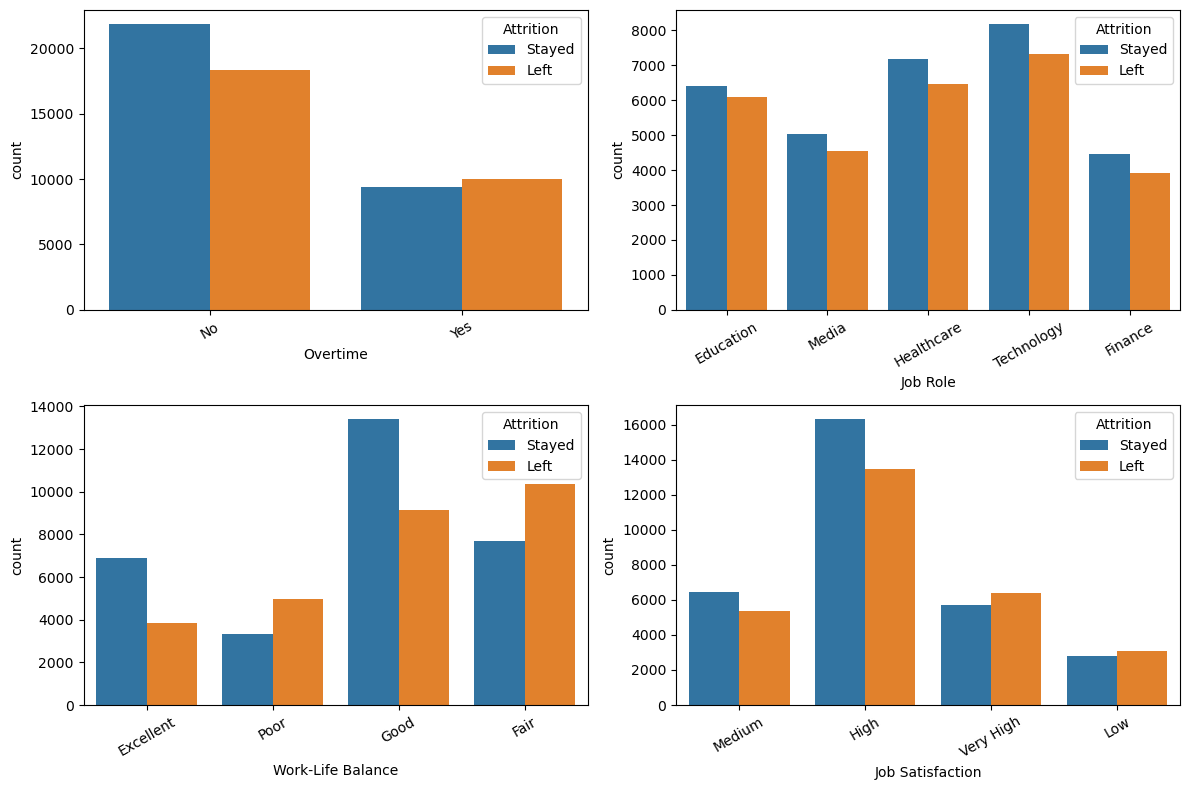

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(
    axes.ravel(),
    ["Overtime", "Job Role", "Work-Life Balance", "Job Satisfaction"]
):
    sns.countplot(data=train_df, x=col, hue="Attrition", ax=ax)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [51]:
X_train = train_df.drop(columns=["Employee ID", "Attrition"])
X_test = test_df.drop(columns=["Employee ID", "Attrition"])

y_train = train_df["Attrition"]
y_test = test_df["Attrition"]

In [52]:
num = X_train.select_dtypes(include="number").columns.tolist()
cat = X_train.select_dtypes(include="object").columns.tolist()

In [53]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num])
X_test_num = scaler.transform(X_test[num])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat])
X_test_cat = encoder.transform(X_test[cat])

In [54]:
X_train_scaled = pd.DataFrame(
    pd.concat([
        pd.DataFrame(X_train_num, columns=num, index=X_train.index),
        pd.DataFrame(
            X_train_cat,
            columns=encoder.get_feature_names_out(cat),
            index=X_train.index
        )
    ], axis=1)
)

X_test_scaled = pd.DataFrame(
    pd.concat([
        pd.DataFrame(X_test_num, columns=num, index=X_test.index),
        pd.DataFrame(
            X_test_cat,
            columns=encoder.get_feature_names_out(cat),
            index=X_test.index
        )
    ], axis=1)
)

In [55]:
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

Accuracy : 0.7483221476510067
Precision: 0.7647210079712008
Recall   : 0.7559735638027453
F1 Score : 0.7603221270612297
ROC-AUC  : 0.8368970496844117

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.74      7032
           1       0.76      0.76      0.76      7868

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



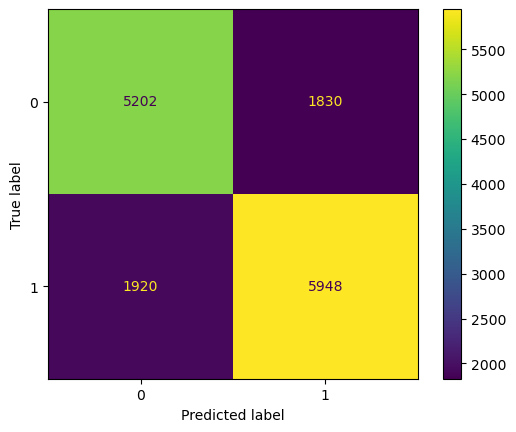

In [56]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


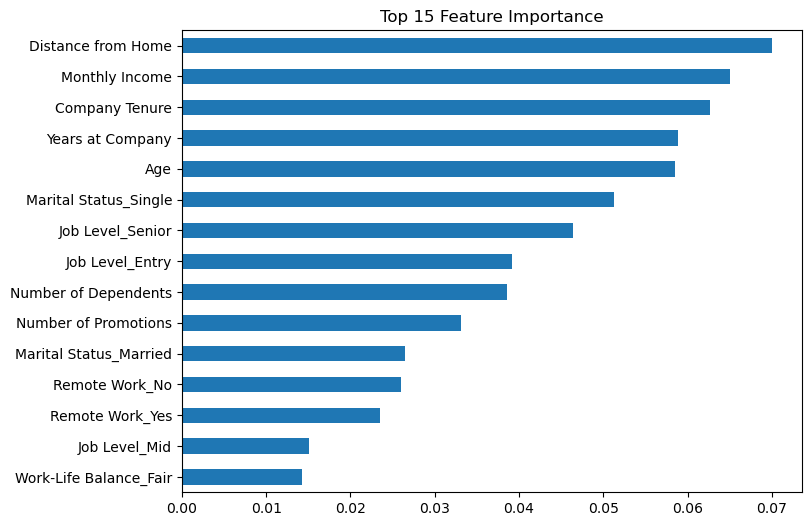

In [57]:
importance = (
    pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
    .sort_values(ascending=False)
    .head(15)
)

importance.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importance")
plt.show()


In [ ]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}

random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [ ]:
best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}
Best CV F1: 0.7638182539914178


In [ ]:
y_predt = best_rf.predict(X_test_scaled)
y_probat = best_rf.predict_proba(X_test_scaled)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Baseline": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ],
    "Tuned": [
        accuracy_score(y_test, y_predt),
        precision_score(y_test, y_predt),
        recall_score(y_test, y_predt),
        f1_score(y_test, y_predt),
        roc_auc_score(y_test, y_probat)
    ]
})

display(comparison)


,Metric,Baseline,Tuned
0,Accuracy,0.748322,0.749799
1,Precision,0.764721,0.755745
2,Recall,0.755974,0.777453
3,F1,0.760322,0.766445
4,ROC-AUC,0.836897,0.841691


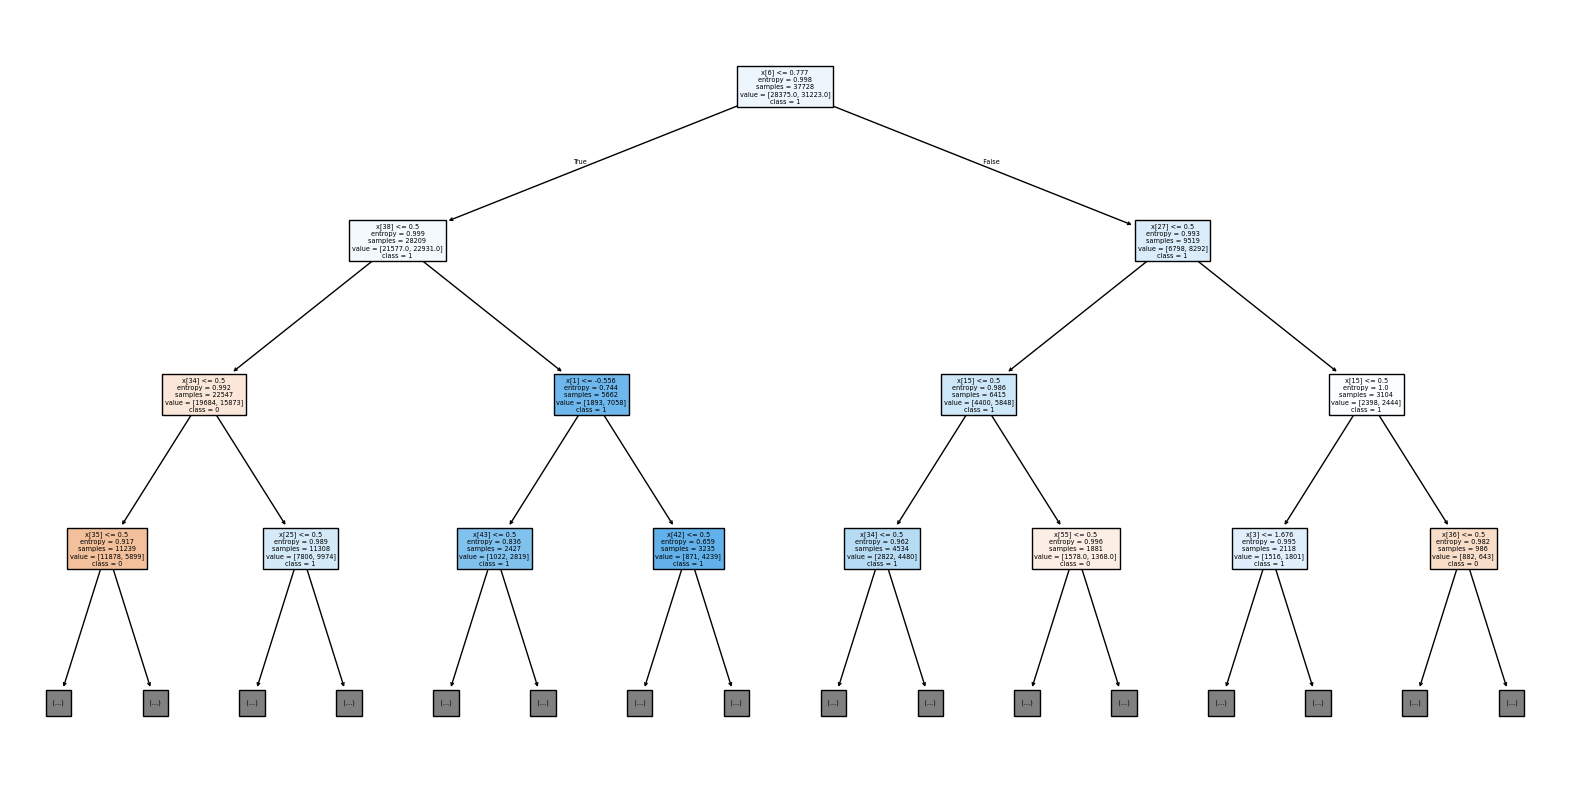

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    best_rf.estimators_[0],
    class_names=["0", "1"],
    filled=True,
    max_depth=3
)

plt.show()

In [ ]:
plt.figure(figsize=(25, 12))

plot_tree(
    best_rf.estimators_[0],
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
    max_depth=3
)

plt.show()